<a href="https://colab.research.google.com/github/Kashishkewat/python_practice/blob/main/day29_python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Logtistic Regression**

**Logistic regression is a classification algorithm used when the output is categorical, most commonly binary:**

# **perceptron trick**

In [104]:
from sklearn.datasets import make_classification
import numpy as np
X,y=make_classification(n_samples=100,n_features=2,n_informative=1,n_redundant=0,n_classes=2,n_clusters_per_class=1,random_state=41,hypercube=False,class_sep=20)

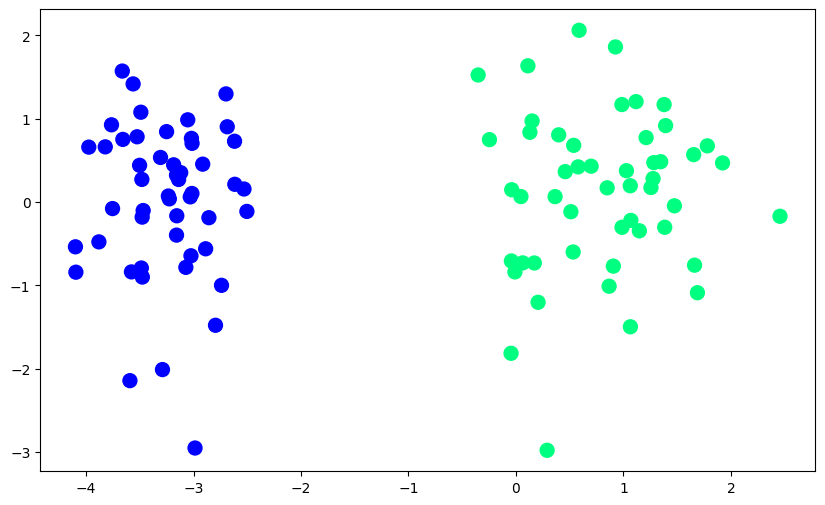

In [105]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.scatter(X[:,0], X[:,1],c=y,cmap='winter',s=100)
plt.show()

In [106]:
def step(z):
  return 1 if z>0 else 0

In [107]:
def perceptron(X,y):
  X=np.insert(X,0,1,axis=1)
  weights=np.ones(X.shape[1])
  lr=0.1
  for i in range(1000):
    j=np.random.randint(0,100)
    y_hat=step(np.dot(X[j],weights))
    weights=weights+lr*(y[j]-y_hat)*X[j]
  return weights[0],weights[1:]

In [108]:
intercept_,coef_=perceptron(X,y)

In [109]:
print(coef_)
print(intercept_)

[0.98628302 0.45500818]
1.3000000000000003


In [110]:
m=-(coef_[0]/coef_[1])
b=-(intercept_/coef_[1])

In [111]:
x_input=np.linspace(-3,3,100)
y_input=m*x_input +b

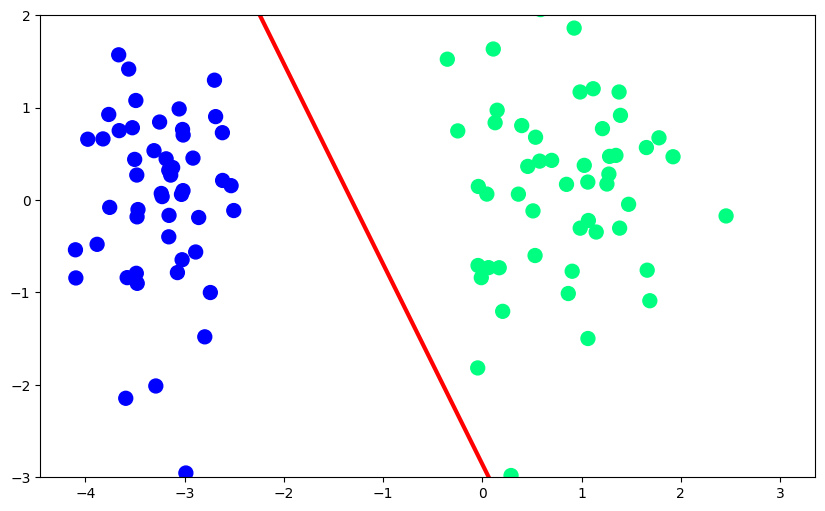

In [112]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)

plt.scatter(X[:,0], X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)
plt.show()

# **logistic regression in sklearn**

In [113]:
from sklearn.linear_model import LogisticRegression
lor=LogisticRegression()
lor.fit(X,y)

LogisticRegression()

In [114]:
m1=-(lor.coef_[0][0]/lor.coef_[0][1])
b1=-(lor.intercept_/lor.coef_[0][1])

In [115]:
x_input1=np.linspace(-3,3,100)
y_input1=m1*x_input1 +b1

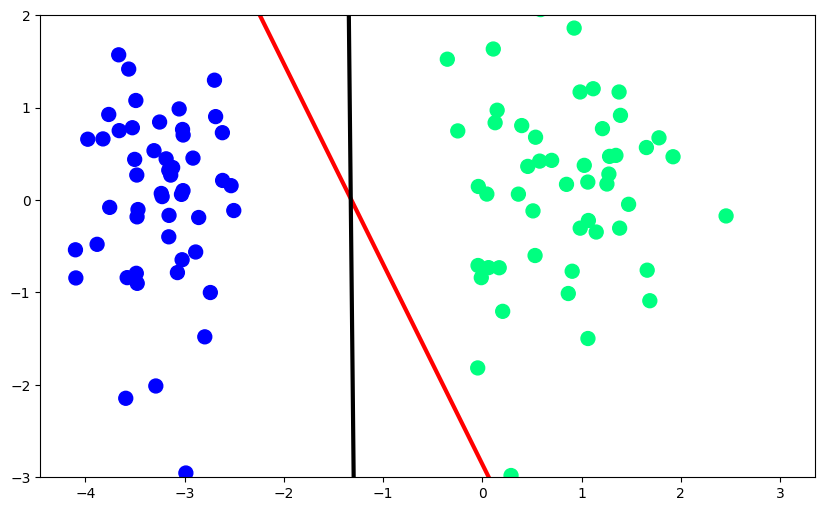

In [116]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.plot(x_input1,y_input1,color='black',linewidth=3)

plt.scatter(X[:,0], X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)
plt.show()

# **Sigmoid Function in logistic regression**

In [117]:
def sigmoid(z):
  return 1/(1+np.exp(-z))

In [118]:
def perceptron_sigmoid(X,y):
  X=np.insert(X,0,1,axis=1)
  weights=np.ones(X.shape[1])
  lr=0.1
  for i in range(1000):
    j=np.random.randint(0,100)
    y_hat=sigmoid(np.dot(X[j],weights))
    weights=weights+lr*(y[j]-y_hat)*X[j]
  return weights[0],weights[1:]

In [119]:
intercept_,coef_=perceptron(X,y)

In [120]:
m2=-(coef_[0]/coef_[1])
b2=-(intercept_/coef_[1])

In [121]:
x_input2=np.linspace(-3,3,100)
y_input2=m2*x_input2 +b2


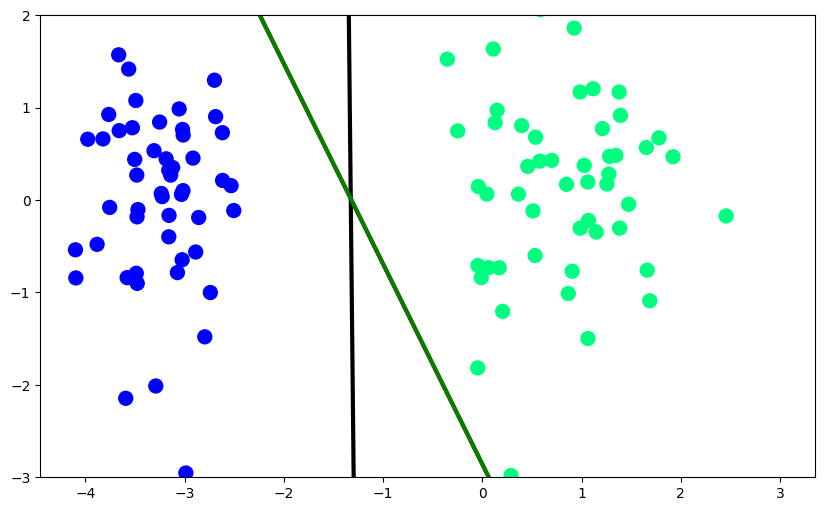

In [122]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.plot(x_input1,y_input1,color='black',linewidth=3)
plt.plot(x_input2,y_input2,color='green',linewidth=3)
plt.scatter(X[:,0], X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)
plt.show()

# **Loss for ONE data point**

For a single example:

Loss(y,y^​)=−[ylog(y^​)+(1−y)log(1−y^​)]

# **logistic regression with gradient descent**

In [123]:
from sklearn.linear_model import LogisticRegression
lor1=LogisticRegression(penalty=None,solver='sag')
lor1.fit(X,y)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(penalty=None, solver='sag')

In [124]:
print(lor1.coef_)
print(lor1.intercept_)

[[4.8324877  0.20617478]]
[5.81726405]


In [125]:
m3=-(lor1.coef_[0][0]/lor1.coef_[0][1])
b3=-(lor1.intercept_/lor1.coef_[0][1])

In [126]:
x_input3=np.linspace(-3,3,100)
y_input3=m3*x_input3 +b3


In [127]:
def sigmoid(z):
  return 1/(1+np.exp(-z))

In [138]:
def gd(X,y):#batch gradient descent
  X=np.insert(X,0,1,axis=1)
  weights=np.ones(X.shape[1])
  lr=0.5
  for i in range(5000):
    y_hat=sigmoid(np.dot(X,weights))
    weights=weights+lr*(np.dot((y-y_hat),X)/X.shape[0])
  return weights[1:],weights[0]

In [134]:
coef_,intercept_=gd(X,y)

In [135]:
m4=-(coef_[0]/coef_[1])
b4=-(  intercept_/coef_[1])

In [136]:
x_input4=np.linspace(-3,3,100)
y_input4=m4*x_input4+b4

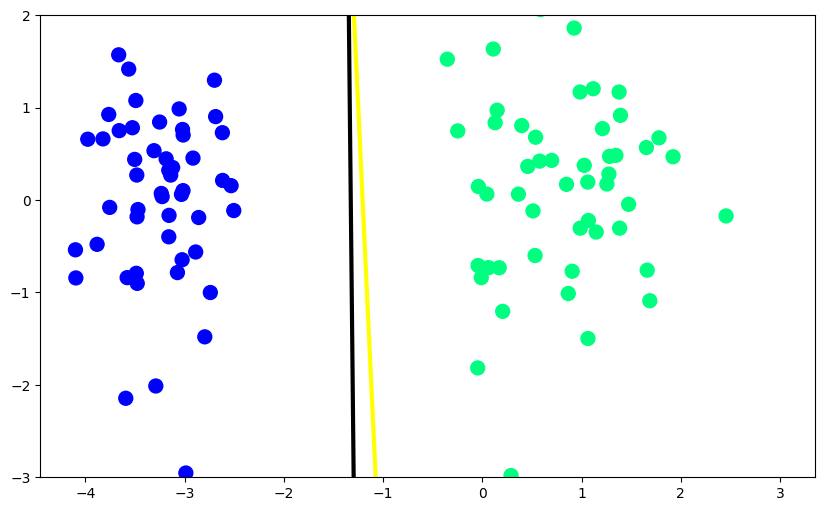

In [137]:
plt.figure(figsize=(10,6))
plt.plot(x_input1,y_input1,color='black',linewidth=3)

plt.plot(x_input4,y_input4,color='yellow',linewidth=3)
plt.scatter(X[:,0], X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)
plt.show()